In [22]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier

%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")

import pandas as pd

pd.set_option("display.max_columns", None)

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler

from src.evaluation import *
from src.visualization import plot_metric_surface

from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")
plt.style.use("default")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

In [3]:
feature_importance_df = pd.read_csv("../outputs/feature_importance_ranking_xgb.csv")

## Best models comparison

In [10]:
MODEL_CONFIGS = {
    "tree": lambda: DecisionTreeClassifier(
        max_depth=3, random_state=42
    ),

    "rf": lambda: RandomForestClassifier(
        n_estimators=200,
        max_depth=3,
        random_state=42,
        n_jobs=-1
    ),

    "extra": lambda: ExtraTreesClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ),
    "LogisticRegression": lambda: LogisticRegression(
        max_iter=10000, C=20
    ),
    "XGBoost": lambda: XGBClassifier(
        max_depth=3,
        learning_rate=0.03,
        n_estimators=300,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

RANKING_METHODS = [
    "mi_rank",
    "f_rank",
    "auc_roc_rank",
    "ks_stat_rank",
    "l1_rank",
    "rf_rank",
    "xgb_rank",
    "avg_normalized_rank",
]

K_VALUES = range(1, 11)

TOP_N_VALUES = [500, 750, 900, 950, 990, 1000]
all_results = []

for rank_method in RANKING_METHODS:

    print(f"\nUsing ranking: {rank_method}")

    sorted_features = (
        feature_importance_df
        .sort_values(rank_method)
        ["feature"]
        .values
    )

    for model_name, model_fn in MODEL_CONFIGS.items():

        print(f"\nRunning model: {model_name}")

        for k in K_VALUES:

            selected_features = sorted_features[:k]
            X_sel = x_train_scaled[selected_features]

            model = model_fn()

            for t in TOP_N_VALUES:
                summary = cross_val_eval(
                    model=model,
                    X=X_sel,
                    y=y_train,
                    n_features=k,
                    model_name=f"{model_name}_k={k}",
                    top_n=t, scaled_features=True
                )

                summary["model_type"] = model_name
                summary["k"] = k
                summary["top_n"] = t
                summary["rank_method"] = rank_method

                all_results.append(summary)

final_results_2 = pd.DataFrame(all_results)


Using ranking: mi_rank

Running model: tree

Running model: rf

Running model: extra

Running model: LogisticRegression

Running model: XGBoost

Using ranking: f_rank

Running model: tree

Running model: rf

Running model: extra

Running model: LogisticRegression

Running model: XGBoost

Using ranking: auc_roc_rank

Running model: tree

Running model: rf

Running model: extra

Running model: LogisticRegression

Running model: XGBoost

Using ranking: ks_stat_rank

Running model: tree

Running model: rf

Running model: extra

Running model: LogisticRegression

Running model: XGBoost

Using ranking: l1_rank

Running model: tree

Running model: rf

Running model: extra

Running model: LogisticRegression

Running model: XGBoost

Using ranking: rf_rank

Running model: tree

Running model: rf

Running model: extra

Running model: LogisticRegression

Running model: XGBoost

Using ranking: xgb_rank

Running model: tree

Running model: rf

Running model: extra

Running model: LogisticRegression

In [12]:
final_results_2.sort_values(by="score", ascending=False).head(20)

,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,f1_std,profit_std,score_std,model,threshold,top_n,model_type,k,rank_method
1643,0.6028,0.751000,0.301855,0.430626,1253.0,1093.0,4,0.013953,0.034169,0.013900,0.019760,102.506097,102.506097,extra_k=4,None,1000,extra,4,rf_rank
1642,0.6020,0.751515,0.299041,0.427838,1242.0,1082.0,4,0.012390,0.030596,0.012332,0.017578,90.870787,90.870787,extra_k=4,None,990,extra,4,rf_rank
1763,0.5992,0.742000,0.298234,0.425462,1226.0,1066.0,4,0.008643,0.021095,0.008593,0.012210,63.285069,63.285069,XGBoost_k=4,None,1000,XGBoost,4,rf_rank
1762,0.5984,0.742424,0.295420,0.422659,1215.0,1055.0,4,0.006950,0.017127,0.006906,0.009841,50.867475,50.867475,XGBoost_k=4,None,990,XGBoost,4,rf_rank
1649,0.6028,0.751000,0.301855,0.430626,1253.0,1053.0,5,0.013517,0.033053,0.013459,0.019129,99.158963,99.158963,extra_k=5,None,1000,extra,5,rf_rank
1637,0.5916,0.723000,0.290599,0.414568,1169.0,1049.0,3,0.012095,0.029707,0.012056,0.017150,89.120705,89.120705,extra_k=3,None,1000,extra,3,rf_rank
1648,0.6028,0.753535,0.299844,0.428987,1248.0,1048.0,5,0.012834,0.031822,0.012795,0.018251,94.511904,94.511904,extra_k=5,None,990,extra,5,rf_rank
1667,0.6180,0.789000,0.317120,0.452406,1367.0,1047.0,8,0.012349,0.031105,0.012444,0.017775,93.313986,93.313986,extra_k=8,None,1000,extra,8,rf_rank
1641,0.5992,0.754737,0.288186,0.417106,1201.0,1041.0,4,0.009311,0.024004,0.009268,0.013371,68.410526,68.410526,extra_k=4,None,950,extra,4,rf_rank
1655,0.6064,0.760000,0.305466,0.435779,1280.0,1040.0,6,0.008204,0.020616,0.008249,0.011781,61.846584,61.846584,extra_k=6,None,1000,extra,6,rf_rank


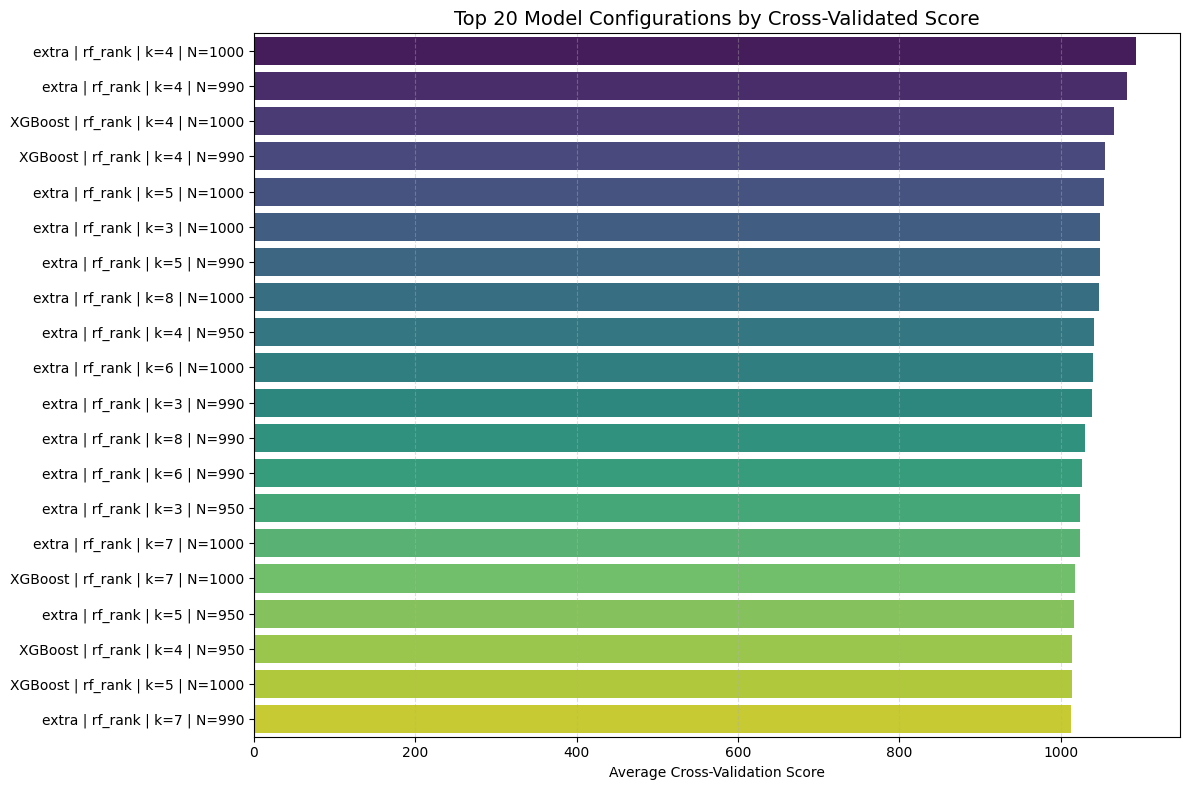

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 20 configurations by score
top_configs = (
    final_results_2
    .sort_values("score", ascending=False)
    .head(20)
    .copy()
)

# Create readable labels
top_configs["config"] = (
        top_configs["model_type"]
        + " | "
        + top_configs["rank_method"]
        + " | k="
        + top_configs["k"].astype(str)
        + " | N="
        + top_configs["top_n"].astype(str)
)

# Plot
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_configs,
    x="score",
    y="config",
    palette="viridis"
)

plt.title("Top 20 Model Configurations by Cross-Validated Score", fontsize=14)
plt.xlabel("Average Cross-Validation Score")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

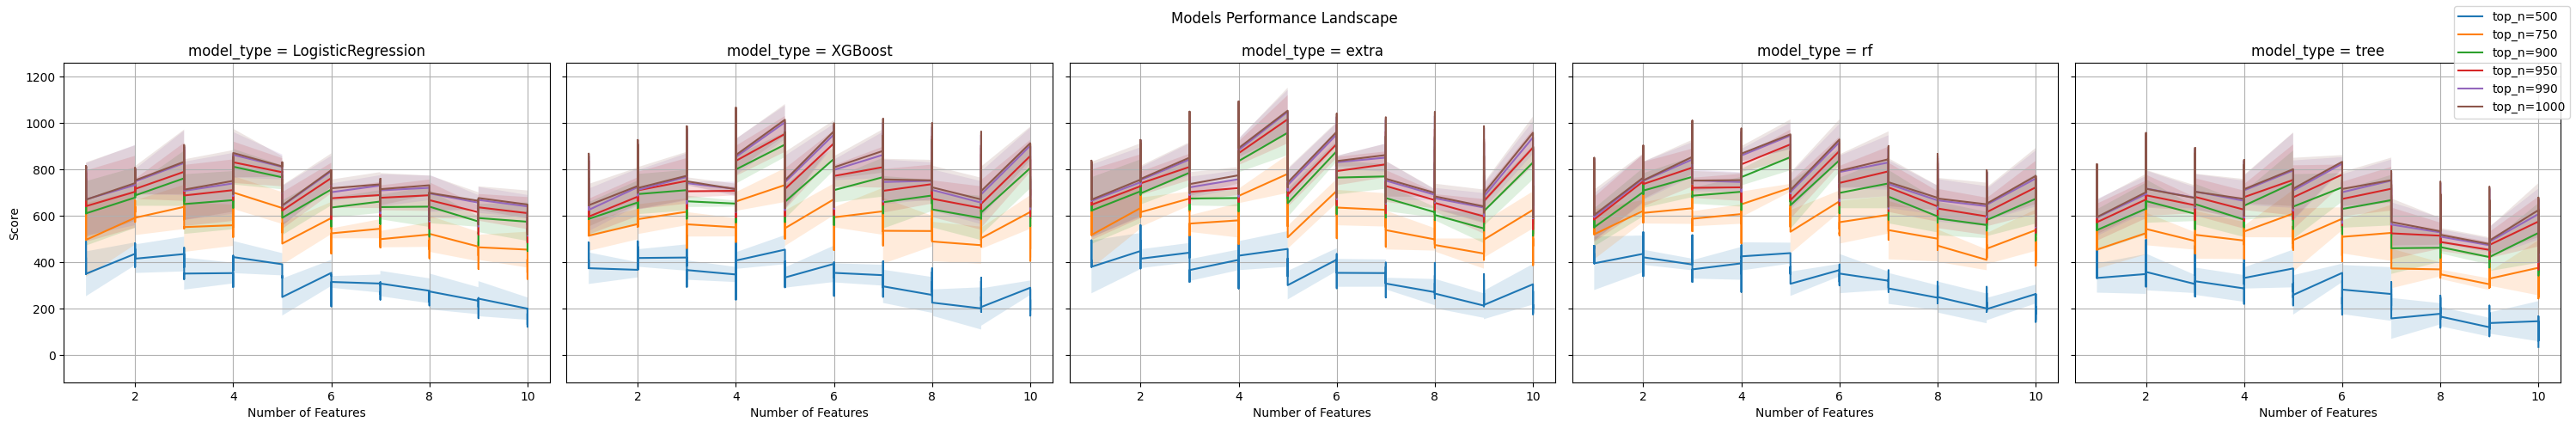

In [24]:
plot_metric_surface(
    df=final_results_2,
    x_col="n_features",
    y_col="score",
    split_col="model_type",
    line_col="top_n",
    std_col="score_std",
    title="Models Performance Landscape",
    x_label="Number of Features",
    y_label="Score"
)

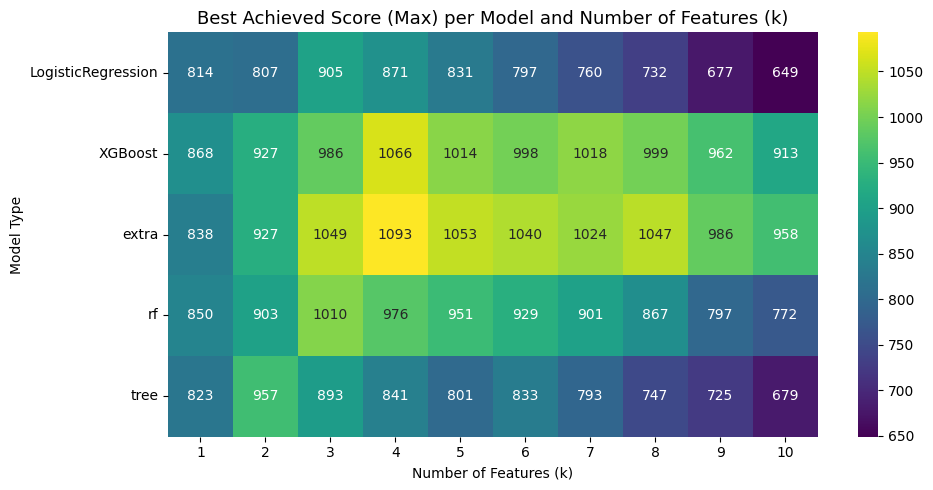

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregate: best possible score per (model, k)
heatmap_data = (
    final_results_2
    .groupby(["model_type", "k"])["score"]
    .max()
    .unstack()
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="viridis"
)

plt.title("Best Achieved Score (Max) per Model and Number of Features (k)", fontsize=13)
plt.xlabel("Number of Features (k)")
plt.ylabel("Model Type")

plt.tight_layout()
plt.show()

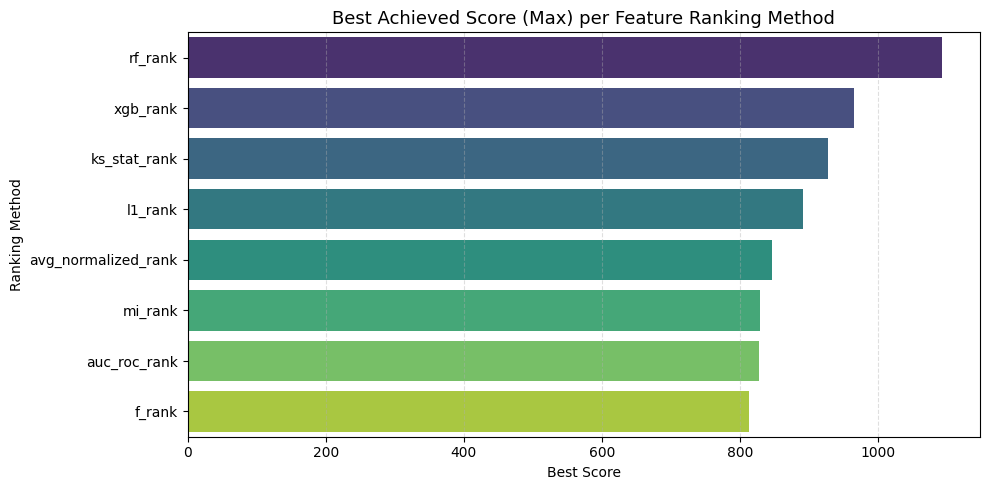

In [26]:
rank_best = (
    final_results_2
    .groupby("rank_method")["score"]
    .max()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=rank_best,
    x="score",
    y="rank_method",
    palette="viridis"
)

plt.title("Best Achieved Score (Max) per Feature Ranking Method", fontsize=13)
plt.xlabel("Best Score")
plt.ylabel("Ranking Method")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Test task

In [30]:
x_test = pd.read_csv("../data/x_test.txt", sep=" ")
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)

model = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
n_features = 4

TOP_N_VALUES = 1000

sorted_features = feature_importance_df.sort_values("rf_rank")["feature"].values

selected_features = sorted_features[:n_features]
X_train_sel = x_train_scaled[selected_features]
X_test_sel = x_test_scaled[selected_features]


model.fit(X_train_sel, y_train)

scores = get_prediction_scores(model, X_test_sel)

preds = top_n_predictions(scores, TOP_N_VALUES)
